# **Principal Component Analysis**(Data Compression)

https://www.bilibili.com/video/BV1E5411E71z/?spm_id_from=333.337.search-card.all.click&vd_source=fe52f800afa6dc19d03ac2d41af5f8a5

In [1812]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat



PCA的核心思想是通过线性变换，将原始高维数据投影到一个新的低维坐标系中。并且确保信息损失最小，这个新坐标系的坐标轴（主成分）是按照**数据方差从大到小**的顺序排列的。

---

### 第一步：中心化（Centering）

这是所有操作的起点。目的是将数据的中心移到原点，便于计算方差和协方差。

**公式：**
$$
\mathbf{x}^{(i)} := \mathbf{x}^{(i)} - \boldsymbol{\mu}
$$
其中，
- $\mathbf{x}^{(i)}$ 是第 $i$ 个样本的原始特征向量（列向量）。
- $\boldsymbol{\mu} = \frac{1}{m} \sum_{i=1}^m \mathbf{x}^{(i)}$ 是所有样本的均值向量。

**矩阵表示：**
将中心化后的 $m$ 个样本（每个样本是 $n$ 维）按行堆叠成数据矩阵 $\mathbf{X}$（$m \times n$ 维），则有：
$$
\mathbf{X}_{\text{centered}} = \mathbf{X} - \mathbf{1} \boldsymbol{\mu}^T
$$
其中 $\mathbf{1}$ 是一个全为1的列向量。

**目的：** 确保数据的均值为零，使得后续的方差计算简化为 $\mathbf{x}^T\mathbf{x}$。

---

### 第二步：计算协方差矩阵（Covariance Matrix）

协方差矩阵 $\mathbf{\Sigma}$ 捕获了数据各个维度（特征）之间的相关性。

**公式：**
$$
\mathbf{\Sigma} = \frac{1}{m} \sum_{i=1}^m \mathbf{x}^{(i)} (\mathbf{x}^{(i)})^T = \frac{1}{m} \mathbf{X}_{\text{centered}}^T \mathbf{X}_{\text{centered}}
$$
其中，
- $\mathbf{\Sigma}$ 是一个 $n \times n$ 的对称矩阵。
- 对角线上的元素 $\Sigma_{jj}$ 是第 $j$ 个特征的**方差**。
- 非对角线上的元素 $\Sigma_{jk}$ 是第 $j$ 个特征和第 $k$ 个特征的**协方差**。

**目的：** 量化数据中各维度之间的关系。PCA的目标就是让新坐标系下的维度间协方差为0（不相关）。

---

### 第三步：特征分解（Eigen Decomposition）

这是PCA的**数学核心**。我们需要找到协方差矩阵 $\mathbf{\Sigma}$ 的特征值和特征向量。

**公式：**
$$
\mathbf{\Sigma} \mathbf{w} = \lambda \mathbf{w}
$$
其中，
- $\lambda$ 是一个**标量**，称为**特征值**。
- $\mathbf{w}$ 是一个 $n$ 维**向量**，称为**特征向量**。

**几何解释：**
特征向量 $\mathbf{w}$ 定义了一个方向，数据在这个方向上的投影方差恰好等于特征值 $\lambda$。**特征值 $\lambda$ 的大小直接代表了数据在该特征向量方向上方差的大小。**

**求解：**
通常求解特征方程 $|\mathbf{\Sigma} - \lambda \mathbf{I}| = 0$ 得到所有特征值 $\lambda_1, \lambda_2, ..., \lambda_n$，再代入原方程求出对应的特征向量 $\mathbf{w}_1, \mathbf{w}_2, ..., \mathbf{w}_n$。

**目的：** 找到数据方差最大的方向（即最大特征值对应的特征向量）。

---

### 第四步：选择主成分并构建投影矩阵

我们需要选择最重要的 $k$ 个主成分来降维。

1.  **排序**：将特征值从大到小排序：$\lambda_1 > \lambda_2 > ... > \lambda_n$。
    其对应的特征向量也按相同顺序排列：$\mathbf{w}_1, \mathbf{w}_2, ..., \mathbf{w}_n$。

2.  **选择k**：选择前 $k$ 个最大的特征值对应的特征向量。
    通常根据**方差解释率（Explained Variance Ratio）**来选择 $k$：
    $$
    \text{Explained Variance Ratio of } \mathbf{w}_j = \frac{\lambda_j}{\sum_{i=1}^n \lambda_i}
    $$
    我们选择最小的 $k$，使得累计方差解释率满足要求（例如 >95%）：
    $$
    \frac{\sum_{j=1}^k \lambda_j}{\sum_{i=1}^n \lambda_i} \geq 0.95
    $$

3.  **构建投影矩阵**：将选定的 $k$ 个特征向量（列向量）并排组成投影矩阵 $\mathbf{W}$。
    $$
    \mathbf{W} = [\mathbf{w}_1, \mathbf{w}_2, ..., \mathbf{w}_k]
    $$
    $\mathbf{W}$ 是一个 $n \times k$ 的矩阵。

**目的：** 构建一个从原始 $n$ 维空间到新 $k$ 维空间的投影映射。

---

### 第五步：投影数据（得到降维后的结果）

将中心化后的原始数据投影到新的主成分方向上，得到降维后的新数据 $\mathbf{Z}$。

**公式：**
$$
\mathbf{z}^{(i)} = \mathbf{W}^T \mathbf{x}^{(i)}
$$
其中，
- $\mathbf{z}^{(i)}$ 是样本 $i$ 在 $k$ 维新空间中的坐标（一个 $k$ 维列向量）。

**矩阵表示（最常用）：**
$$
\mathbf{Z} = \mathbf{X}_{\text{centered}} \mathbf{W}
$$
其中，
- $\mathbf{X}_{\text{centered}}$ 是 $m \times n$ 的中心化数据矩阵。
- $\mathbf{W}$ 是 $n \times k$ 的投影矩阵。
- $\mathbf{Z}$ 是 $m \times k$ 的降维后的新数据矩阵。

**目的：** 得到降维后且各维度不相关的数据集。

---

### 总结：PCA的数学目标

从优化角度看，PCA求解的是一个**最大化方差**的问题。

**第一主成分 $\mathbf{w}_1$ 的求解：**
$$
\begin{align*}
&\max_{\mathbf{w}_1} \quad \frac{1}{m} \sum_{i=1}^m (\mathbf{w}_1^T \mathbf{x}^{(i)})^2 = \mathbf{w}_1^T \mathbf{\Sigma} \mathbf{w}_1 \\
&\text{subject to} \quad \|\mathbf{w}_1\|^2_2 = 1
\end{align*}
$$
**约束条件 $\|\mathbf{w}_1\|_2 = 1$ 是为了确保解是唯一的方向，而不是无限长。**

**后续主成分的求解：**
第 $j$ 个主成分 $\mathbf{w}_j$ 不仅要最大化方差，还必须与之前的所有主成分正交（不相关）：
$$
\begin{align*}
&\max_{\mathbf{w}_j} \quad \mathbf{w}_j^T \mathbf{\Sigma} \mathbf{w}_j \\
&\text{subject to} \quad \|\mathbf{w}_j\|^2_2 = 1, \quad \mathbf{w}_j^T \mathbf{w}_i = 0 \quad \text{for all } i < j
\end{align*}
$$

**而特征分解（$\mathbf{\Sigma} \mathbf{w} = \lambda \mathbf{w}$）恰好是这个优化问题的最优解。** 最大的特征值 $\lambda_1$ 对应最大方差，其特征向量 $\mathbf{w}_1$ 就是第一主成分的方向。

通过这一系列的数学步骤，PCA成功地将原始相关的高维数据，转换成了用一组**互不相关**、**按方差大小排序**的**新特征**表示的低维数据。

In [1813]:
data = loadmat('data/ex7data1.mat')
X = data['X']

# check
X.shape
(np.sum(X,axis=1)/X.shape[0]).shape

(50,)

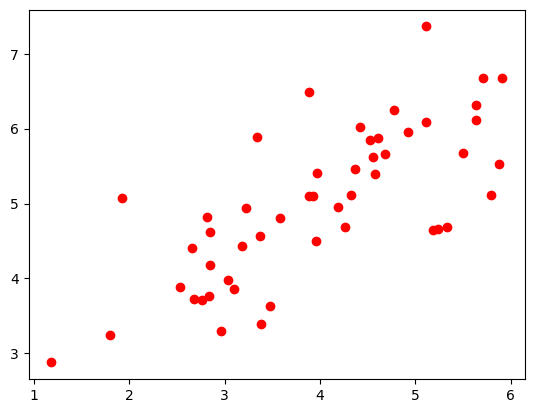

In [1814]:
# scatter the point
plt.scatter(X[:,0],X[:,1],c='r',marker='o')
plt.show()

In [1815]:
def PCA(X:np.ndarray,k:int)->tuple[np.ndarray,np.ndarray]:
    """
    X:(m,n)  m samples, n dimension
    """
    # 1.Standardization (or centering, we choose standardization here)
    m,n = X.shape
    if (k>n):
        return X
    
    # mu = np.sum(X,axis=0)/m
    # sigma = np.sqrt(np.sum(np.power(X-mu,2),axis=0)/m) # /m-1  可以获得无偏估计
    # X_std = (X - mu)/sigma # 不需要除sigma

    X_std = (X - X.mean(axis=0)) / X.std(axis=0)

    Cov = (X_std.T @ X_std)/ (m -1) # (n,n)
    print(Cov)

    # find features values and vectors
    eigen_values,eigen_vects = np.linalg.eig(Cov)
    # print(eigen_vects)

    # fetch the largest k features values (meaning to reduce dimension to k)
    sorted_idx = np.argsort(eigen_values)[::-1]# [strat:end:step] 获得升序数组反转为降序

    # eigen_values = eigen_values[sorted_idx][:k]
    print(eigen_values)
    eigen_vects = eigen_vects[:,sorted_idx]
    print(eigen_vects)
    eigen_vects = eigen_vects[:,:k] # (n,k)

    # print(eigen_vects)

    # project data
    X_pca = X @ (eigen_vects) # (m,n)x(n,k)

    # print(X_pca)

    return X_pca,eigen_vects

In [1816]:
# apply pca
m,n=X.shape
X_pca,U= PCA(X,n-1)


[[1.02040816 0.7505412 ]
 [0.7505412  1.02040816]]
[1.77094936 0.26986696]
[[ 0.70710678 -0.70710678]
 [ 0.70710678  0.70710678]]


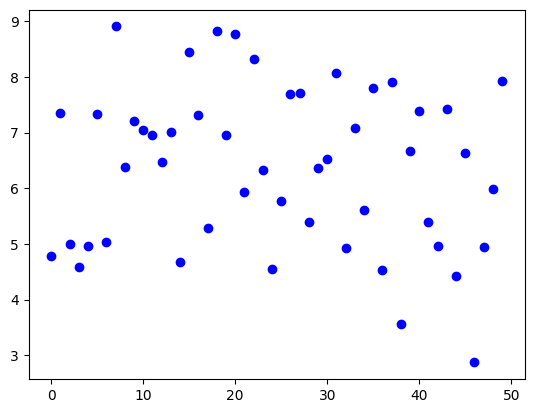

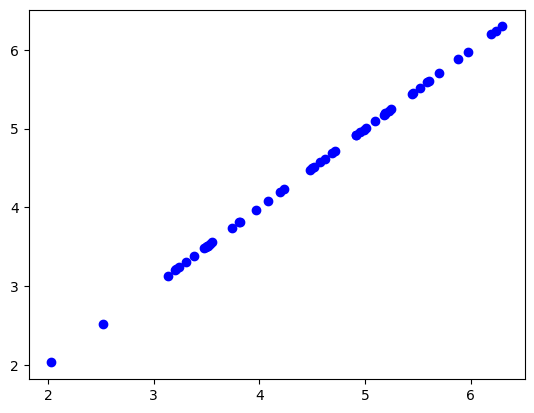

In [1817]:

plt.scatter(np.arange(m),(X_pca[:,0]),c='b',marker='o')
plt.show()

X_pca = np.dot(X_pca,U.T)
plt.scatter(X_pca[:,0],X_pca[:,1],c='b',marker='o')

SVD(scratch  )

In [1818]:
def pca_svd(X, k) -> tuple[np.ndarray, np.ndarray]:
    m,n=X.shape
    # 数据标准化
    X_std = (X - X.mean(axis=0)) / X.std(axis=0)
    

    # 使用SVD直接分解数据矩阵
    U, s, V = np.linalg.svd(X_std / np.sqrt(m - 1), full_matrices=False) # svd的输入是原始数据矩阵 ， X_std / np.sqrt(m-1) 相当于对x_std.T @ x_std 除以m-1
    print(s)
    # 选择前k个主成分
    print(V.T)
    vects = V.T[:,:k]  # Vt的行是特征向量
    

    # 投影
    X_pca = X_std @ vects

    return X_pca, vects

In [1819]:
# apply pca
m,n=X.shape
X_pca ,U= pca_svd(X,n-1)

[1.33077021 0.51948721]
[[ 0.70710678  0.70710678]
 [ 0.70710678 -0.70710678]]


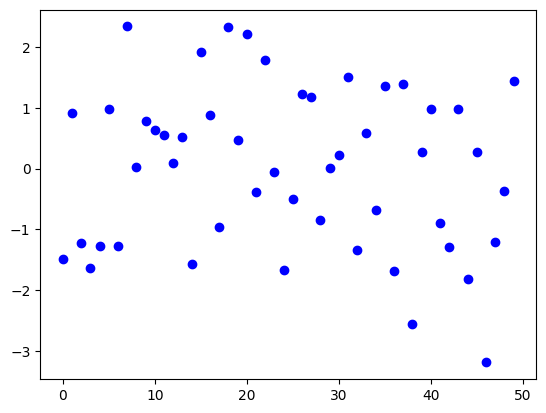

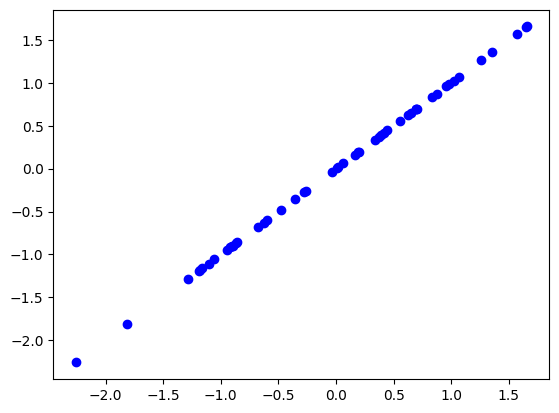

In [1820]:

plt.scatter(np.arange(m),(X_pca[:,0]),c='b',marker='o')
plt.show()

X_pca = np.dot(X_pca,U.T)
plt.scatter(X_pca[:,0],X_pca[:,1],c='b',marker='o')

In [1821]:
def PCA2(X:np.ndarray,k:int):
    """
    X:(m,n)  m samples, n dimension
    """
    m,n = X.shape
    if (k>n):
        return X
    
    # X_std=(X-X.mean())/X.std() # 整个矩阵而没有对某维度
    # Cov = (X_std.T @ X_std)/X_std.shape[0]

    X_std = X

    Cov = (X_std.T @ X_std)/m # (n,n)
    print(Cov)

    # find features values and vectors
    eigen_values,eigen_vects = np.linalg.eig(Cov)
    # print(eigen_vects)

    # fetch the largest k features values (meaning to reduce dimension to k)
    sorted_idx = np.argsort(eigen_values)[::-1]# [strat:end:step] 获得升序数组反转为降序

    # eigen_values = eigen_values[sorted_idx][:k]
    eigen_vects = eigen_vects[:,sorted_idx]
    print(eigen_vects)
    eigen_vects = eigen_vects[:,:k] # (n,k)

    # print(eigen_vects)

    # project data
    X_pca = X @ (eigen_vects) # (m,n)x(n,k)
    X_pca = X_pca @ eigen_vects.T

    # print(X_pca)    
    return X_pca

### 接下来对脸部图像做降维处理提取脸部特征

In [1822]:
faces = loadmat('data/ex7faces.mat')
X = faces['X']
X.shape
# 反色处理
X = 255-np.abs(X)


In [1823]:
img_width = int(np.sqrt(1024))

In [1824]:
def plot_n_images(X:np.ndarray,width:int=5)->np.ndarray:
    num,size = X.shape
    img_width = int(np.sqrt(size))
    merged_img = np.zeros((num*img_width,width*img_width))
    for i in range(num):
        img = X[i]
        img = img.reshape(img_width,-1).T
        pos_y = int(i/width)
        pos_x = i % width
        merged_img[\
            pos_y*img_width: (pos_y+1)*img_width,\
            pos_x*img_width: (pos_x+1)*img_width
            ]=img
    return merged_img

In [1825]:
imges = plot_n_images(X)
imges

array([[217.13368613, 229.13368613, 238.13368613, ..., 239.13368613,
        234.13368613, 233.13368613],
       [209.13368613, 221.13368613, 238.13368613, ..., 248.86631387,
        241.13368613, 232.13368613],
       [201.13368613, 216.13368613, 230.13368613, ..., 244.86631387,
        251.13368613, 233.13368613],
       ...,
       [  0.        ,   0.        ,   0.        , ...,   0.        ,
          0.        ,   0.        ],
       [  0.        ,   0.        ,   0.        , ...,   0.        ,
          0.        ,   0.        ],
       [  0.        ,   0.        ,   0.        , ...,   0.        ,
          0.        ,   0.        ]])

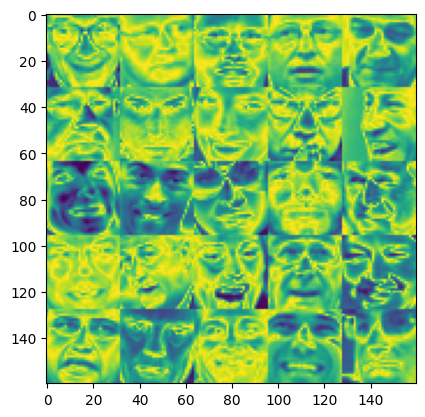

In [1826]:
plt.imshow(imges[:5*img_width,:].astype('uint8'))

可以看出来这些是一些灰度图像

[[45134.67072084 45298.45263709 45454.33291122 ... 42828.07891657
  42360.19252657 42059.02546873]
 [45298.45263709 45553.94699911 45746.42921886 ... 43038.39174613
  42569.08994511 42267.11749338]
 [45454.33291122 45746.42921886 46052.17771676 ... 43283.58157686
  42812.37968837 42506.48466947]
 ...
 [42828.07891657 43038.39174613 43283.58157686 ... 43010.29374721
  42483.36726305 42059.4784819 ]
 [42360.19252657 42569.08994511 42812.37968837 ... 42483.36726305
  42134.71644721 41754.31180207]
 [42059.02546873 42267.11749338 42506.48466947 ... 42059.4784819
  41754.31180207 41550.90389161]]
[[-2.98881530e-02 -4.95379544e-02  9.01991311e-03 ... -3.62275423e-03
   3.73772926e-03  2.32862510e-03]
 [-3.00396420e-02 -5.27138245e-02  8.37505015e-03 ...  9.09387963e-03
  -7.35103848e-03 -3.56274238e-03]
 [-3.02171980e-02 -5.53032072e-02  7.01347557e-03 ... -6.67763769e-03
   3.97487647e-03 -3.43974046e-03]
 ...
 [-2.90737233e-02  5.13535983e-02  4.34307004e-02 ...  3.57832828e-03
  -1.635490

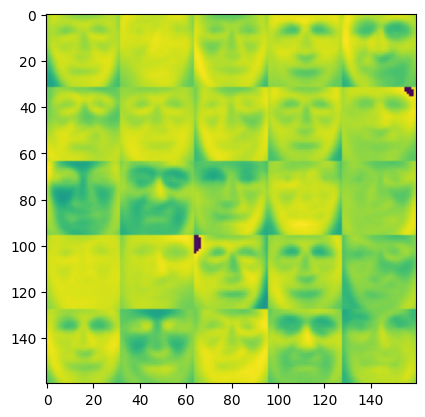

In [1827]:
# unstandardized PCA
X_plot=PCA2(X,10)

print(X_plot.shape)
img_width = int(np.sqrt(X_plot.shape[1]))
imges_pca = plot_n_images(X_plot)

plt.imshow(imges_pca[:5*img_width,:].astype('uint8'))


[[ 1.00020004  0.95696369  0.86834571 ... -0.04871427 -0.05515126
  -0.0431673 ]
 [ 0.95696369  1.00020004  0.94548607 ... -0.05442004 -0.06012889
  -0.04729144]
 [ 0.86834571  0.94548607  1.00020004 ... -0.06214673 -0.06717621
  -0.05591603]
 ...
 [-0.04871427 -0.05442004 -0.06214673 ...  1.00020004  0.93303199
   0.83555566]
 [-0.05515126 -0.06012889 -0.06717621 ...  0.93303199  1.00020004
   0.93345092]
 [-0.0431673  -0.04729144 -0.05591603 ...  0.83555566  0.93345092
   1.00020004]]
[1.75508550e+02 7.99972828e+01 7.63163663e+01 ... 1.68122487e-02
 1.69223763e-02 1.66186688e-02]
[[-0.01442493 -0.03156498 -0.02869499 ... -0.00665328 -0.00550983
  -0.00303389]
 [-0.01484951 -0.03313734 -0.03159239 ...  0.01553807  0.01010345
   0.00459744]
 [-0.01549306 -0.03398936 -0.03434662 ... -0.01081542 -0.00436857
   0.0042198 ]
 ...
 [-0.01104603 -0.00442282  0.04122468 ...  0.00542312  0.00197206
  -0.00228444]
 [-0.00957351 -0.00340652  0.03837155 ... -0.00505935 -0.00027697
   0.00360244]
 

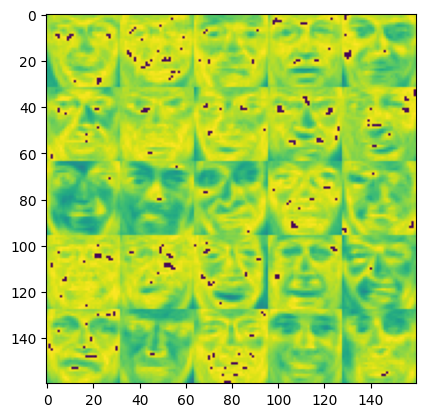

In [1828]:

X_pca,U = PCA(X,100)
X_plot = np.dot(X_pca,U.T)

img_width = int(np.sqrt(X_plot.shape[1]))
imges_pca = plot_n_images(X_plot)

plt.imshow(imges_pca[0*img_width:5*img_width,:].astype('uint8'))

[[ 1.00020004  0.95696369  0.86834571 ... -0.04871427 -0.05515126
  -0.0431673 ]
 [ 0.95696369  1.00020004  0.94548607 ... -0.05442004 -0.06012889
  -0.04729144]
 [ 0.86834571  0.94548607  1.00020004 ... -0.06214673 -0.06717621
  -0.05591603]
 ...
 [-0.04871427 -0.05442004 -0.06214673 ...  1.00020004  0.93303199
   0.83555566]
 [-0.05515126 -0.06012889 -0.06717621 ...  0.93303199  1.00020004
   0.93345092]
 [-0.0431673  -0.04729144 -0.05591603 ...  0.83555566  0.93345092
   1.00020004]]
[1.75508550e+02 7.99972828e+01 7.63163663e+01 ... 1.68122487e-02
 1.69223763e-02 1.66186688e-02]
[[-0.01442493 -0.03156498 -0.02869499 ... -0.00665328 -0.00550983
  -0.00303389]
 [-0.01484951 -0.03313734 -0.03159239 ...  0.01553807  0.01010345
   0.00459744]
 [-0.01549306 -0.03398936 -0.03434662 ... -0.01081542 -0.00436857
   0.0042198 ]
 ...
 [-0.01104603 -0.00442282  0.04122468 ...  0.00542312  0.00197206
  -0.00228444]
 [-0.00957351 -0.00340652  0.03837155 ... -0.00505935 -0.00027697
   0.00360244]
 

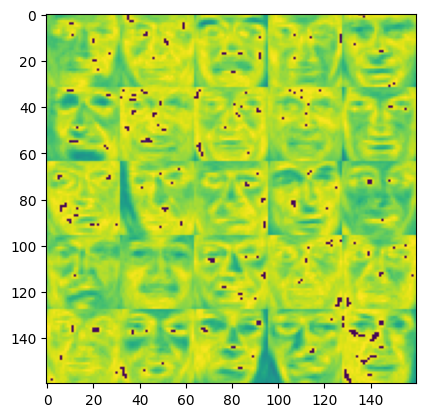

In [1829]:
X_pca,U = PCA(X,100)

X_plot = np.dot(X_pca,U.T)
img_width = int(np.sqrt(X_plot.shape[1]))
imges_pca = plot_n_images(X_plot)
gap = 5
start = 990
plt.imshow(imges_pca[start*img_width:(start+gap)*img_width,:].astype('uint8'))

[[ 1.00020004  0.95696369  0.86834571 ... -0.04871427 -0.05515126
  -0.0431673 ]
 [ 0.95696369  1.00020004  0.94548607 ... -0.05442004 -0.06012889
  -0.04729144]
 [ 0.86834571  0.94548607  1.00020004 ... -0.06214673 -0.06717621
  -0.05591603]
 ...
 [-0.04871427 -0.05442004 -0.06214673 ...  1.00020004  0.93303199
   0.83555566]
 [-0.05515126 -0.06012889 -0.06717621 ...  0.93303199  1.00020004
   0.93345092]
 [-0.0431673  -0.04729144 -0.05591603 ...  0.83555566  0.93345092
   1.00020004]]
[1.75508550e+02 7.99972828e+01 7.63163663e+01 ... 1.68122487e-02
 1.69223763e-02 1.66186688e-02]
[[-0.01442493 -0.03156498 -0.02869499 ... -0.00665328 -0.00550983
  -0.00303389]
 [-0.01484951 -0.03313734 -0.03159239 ...  0.01553807  0.01010345
   0.00459744]
 [-0.01549306 -0.03398936 -0.03434662 ... -0.01081542 -0.00436857
   0.0042198 ]
 ...
 [-0.01104603 -0.00442282  0.04122468 ...  0.00542312  0.00197206
  -0.00228444]
 [-0.00957351 -0.00340652  0.03837155 ... -0.00505935 -0.00027697
   0.00360244]
 

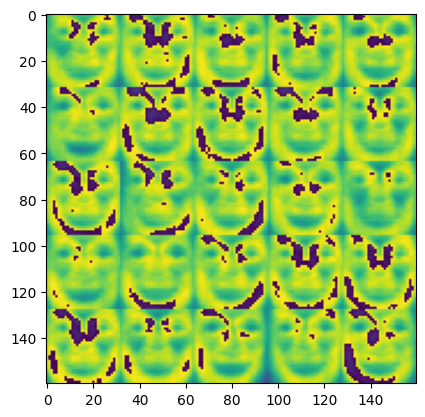

In [1830]:
X_pca,U = PCA(X,10)

X_plot = np.dot(X_pca,U.T)
img_width = int(np.sqrt(X_plot.shape[1]))
imges_pca = plot_n_images(X_plot)
gap = 5
start = 990
plt.imshow(imges_pca[start*img_width:(start+gap)*img_width,:].astype('uint8'))

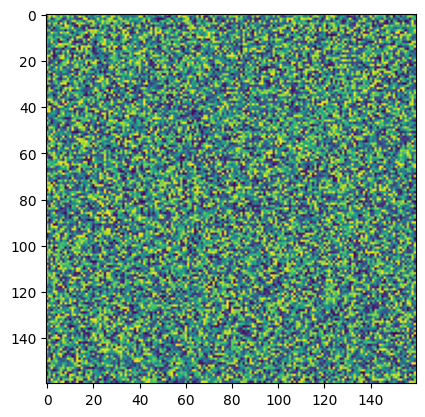

In [1831]:
X_unstd = X_plot * X.std(axis=0)+X.mean(axis=0)
imges_pca = plot_n_images(X_unstd)
plt.imshow(imges_pca[start*img_width:(start+gap)*img_width,:].astype('uint8'))

### svd版本

[13.24796398  8.94412001  8.7359239  ...  0.05570774  0.05439178
  0.05065524]
[[-0.01442493 -0.03156498  0.02869499 ...  0.00665328 -0.00550983
   0.00303389]
 [-0.01484951 -0.03313734  0.03159239 ... -0.01553807  0.01010345
  -0.00459744]
 [-0.01549306 -0.03398936  0.03434662 ...  0.01081542 -0.00436857
  -0.0042198 ]
 ...
 [-0.01104603 -0.00442282 -0.04122468 ... -0.00542312  0.00197206
   0.00228444]
 [-0.00957351 -0.00340652 -0.03837155 ...  0.00505935 -0.00027697
  -0.00360244]
 [-0.00877221 -0.00270805 -0.03547118 ... -0.00136177 -0.00046711
   0.00548405]]


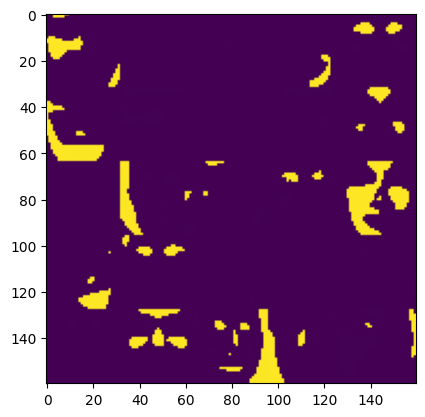

In [1832]:
X_pca_svd,U = pca_svd(X,10)

X_plot_svd = np.dot(X_pca_svd,U.T)

img_width = int(np.sqrt(X_plot_svd.shape[1]))
imges_pca = plot_n_images(X_plot_svd)
gap = 5
start = 990
plt.imshow(imges_pca[start*img_width:(start+gap)*img_width,:].astype('uint8'))

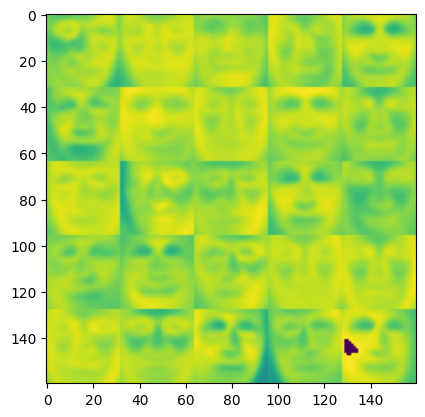

In [1833]:
X_unstd = X_plot_svd * X.std(axis=0)+X.mean(axis=0)
imges_pca = plot_n_images(X_unstd)
plt.imshow(imges_pca[start*img_width:(start+gap)*img_width,:].astype('uint8'))

[13.24796398  8.94412001  8.7359239  ...  0.05570774  0.05439178
  0.05065524]
[[-0.01442493 -0.03156498  0.02869499 ...  0.00665328 -0.00550983
   0.00303389]
 [-0.01484951 -0.03313734  0.03159239 ... -0.01553807  0.01010345
  -0.00459744]
 [-0.01549306 -0.03398936  0.03434662 ...  0.01081542 -0.00436857
  -0.0042198 ]
 ...
 [-0.01104603 -0.00442282 -0.04122468 ... -0.00542312  0.00197206
   0.00228444]
 [-0.00957351 -0.00340652 -0.03837155 ...  0.00505935 -0.00027697
  -0.00360244]
 [-0.00877221 -0.00270805 -0.03547118 ... -0.00136177 -0.00046711
   0.00548405]]


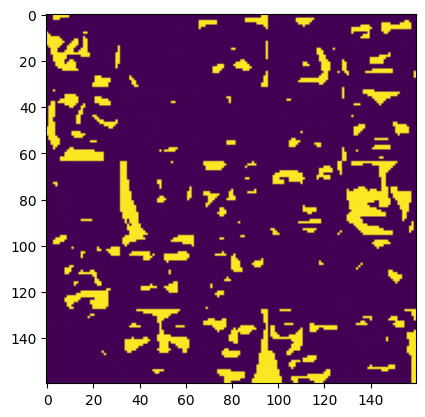

In [1834]:
X_pca_svd,U = pca_svd(X,100)
X_plot_svd = np.dot(X_pca_svd,U.T)

img_width = int(np.sqrt(X_plot_svd.shape[1]))
imges_pca = plot_n_images(X_plot_svd)
gap = 5
start = 990
plt.imshow(imges_pca[start*img_width:(start+gap)*img_width,:].astype('uint8'))


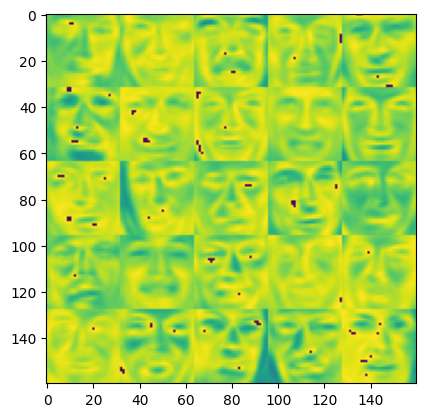

In [1835]:
X_unstd = X_plot_svd * X.std(axis=0)+X.mean(axis=0)
imges_pca = plot_n_images(X_unstd)
plt.imshow(imges_pca[start*img_width:(start+gap)*img_width,:].astype('uint8'))

### 为什么svd版本和直接求特征向量版本不一样？？

In [1836]:
def pca_svd_simple(X, k):
    """最简单的PCA实现"""
    X_std = (X - np.mean(X, axis=0)) / np.std(X, axis=0)
    U, s, Vt = np.linalg.svd(X_std)
    return X_std @ Vt[:k].T, Vt[:k].T

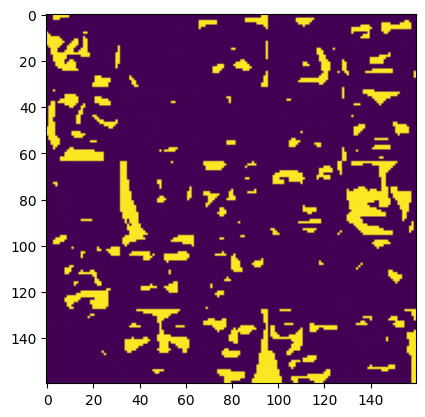

In [1837]:
X_pca2,U2 = pca_svd_simple(X,100)

X_plot2 = np.dot(X_pca2,U2.T)

img_width = int(np.sqrt(X_plot2.shape[1]))
imges_pca = plot_n_images(X_plot2)
gap = 5
start = 990
plt.imshow(imges_pca[start*img_width:(start+gap)*img_width,:].astype('uint8'))